# Laboratorio 09: Datos Sintéticos

In [1]:
pip install faker

Note: you may need to restart the kernel to use updated packages.


In [2]:
from faker import Faker
import pandas as pd
import random

In [3]:
fake = Faker("es_MX")

In [24]:
#Generamos datos sintéticos: 100 registros
datos = []
for i in range(1000): 
    datos.append({
        "id_usuario": i + 1,
        "nombre": fake.name(),
        "correo": fake.email(),
        "edad": random.randint(18,65),
        "seguidores": random.randint(100, 50000),
        "plataforma": random.choice(
            ["TikTok", "Instagram", "Youtube"]
        )
    })

In [25]:
df = pd.DataFrame(datos)
df.head()

,id_usuario,nombre,correo,edad,seguidores,plataforma
0,1,Lic. Ricardo Correa,griegomaria-elena@example.net,30,8034,Youtube
1,2,Joaquín Francisco Benítez,almade-la-o@example.org,43,1649,Youtube
2,3,Mónica Riojas Cano,beltranrosalia@example.com,19,31480,Instagram
3,4,Alvaro Evelio Hurtado Cazares,alejandroasuncion@example.com,41,20025,TikTok
4,5,Guadalupe Lucio Arellano,lilianazamudio@example.net,53,18629,Youtube


In [26]:
#Exploración del DataSet
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id_usuario  1000 non-null   int64
 1   nombre      1000 non-null   str  
 2   correo      1000 non-null   str  
 3   edad        1000 non-null   int64
 4   seguidores  1000 non-null   int64
 5   plataforma  1000 non-null   str  
dtypes: int64(3), str(3)
memory usage: 47.0 KB


In [27]:
#Estadística descriptiva
df.describe(include = "all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,1000.000000,1000,1000,1000.000000,1000.000000,1000
unique,NaN,1000,999,NaN,NaN,3
top,NaN,Lic. Ricardo Correa,fidel22@example.com,NaN,NaN,TikTok
freq,NaN,1,2,NaN,NaN,369
mean,500.500000,NaN,NaN,41.939000,24979.981000,NaN
std,288.819436,NaN,NaN,13.795492,14302.949968,NaN
min,1.000000,NaN,NaN,18.000000,113.000000,NaN
25%,250.750000,NaN,NaN,30.000000,12456.000000,NaN
50%,500.500000,NaN,NaN,42.500000,24669.000000,NaN
75%,750.250000,NaN,NaN,53.250000,37526.500000,NaN


In [28]:
#Importar librerias para graficar
import seaborn as sns
import matplotlib.pyplot as plt

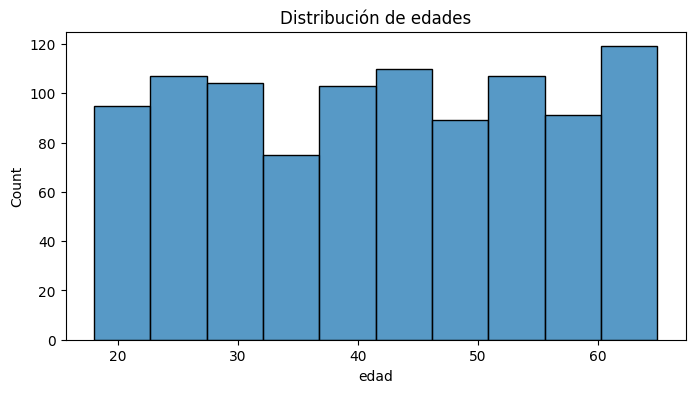

In [29]:
#Distribución de edades
plt.figure(figsize = (8,4))
sns.histplot(
    df["edad"],
    bins = 10
)
plt.title("Distribución de edades")
plt.show()

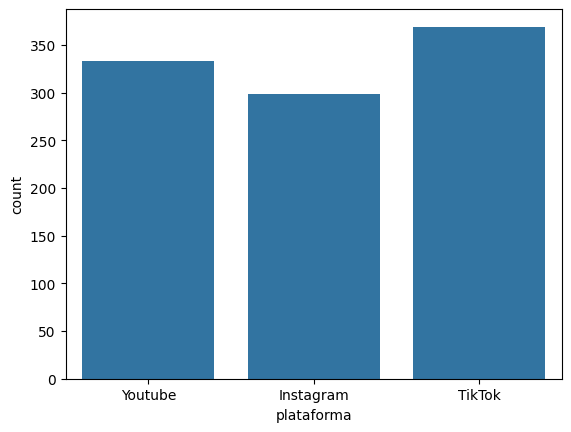

In [30]:
#Usuarios por plataforma
sns.countplot(
    x = "plataforma",
    data = df
)
plt.show()

In [31]:
#Generamos una copia para contaminarla
df_sucio = df.copy()

In [32]:
#Le colocamos valores nulos
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "nombre"] = None

In [33]:
df_sucio.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id_usuario  1000 non-null   int64
 1   nombre      995 non-null    str  
 2   correo      1000 non-null   str  
 3   edad        1000 non-null   int64
 4   seguidores  1000 non-null   int64
 5   plataforma  1000 non-null   str  
dtypes: int64(3), str(3)
memory usage: 47.0 KB


In [34]:
#Edades invalidas
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "edad"] = -10

In [35]:
df_sucio.describe()["edad"]

count    1000.000000
mean       41.666000
std        14.217897
min       -10.000000
25%        30.000000
50%        42.000000
75%        53.000000
max        65.000000
Name: edad, dtype: float64

In [36]:
#Seguidores imposibles
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "seguidores"] = 5000000

In [37]:
df_sucio.describe()["seguidores"]

count    1.000000e+03
mean     4.984217e+04
std      3.513729e+05
min      1.130000e+02
25%      1.252650e+04
50%      2.479000e+04
75%      3.771150e+04
max      5.000000e+06
Name: seguidores, dtype: float64

In [38]:
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "correo"] = "correo_invalido"

In [42]:
df_sucio.describe(include = ["str", "object"])

,nombre,correo,plataforma
count,995,1000,1000
unique,995,995,3
top,Lic. Ricardo Correa,correo_invalido,TikTok
freq,1,5,369


In [43]:
df_sucio.isnull().sum()

id_usuario    0
nombre        5
correo        0
edad          0
seguidores    0
plataforma    0
dtype: int64

In [46]:
pd.set_option("display.float_format", lambda x: "{:.2f}".format(x))

In [47]:
#Estadisticas
df_sucio.describe(include = "all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,1000.00,995,1000,1000.00,1000.00,1000
unique,NaN,995,995,NaN,NaN,3
top,NaN,Lic. Ricardo Correa,correo_invalido,NaN,NaN,TikTok
freq,NaN,1,5,NaN,NaN,369
mean,500.50,NaN,NaN,41.67,49842.17,NaN
std,288.82,NaN,NaN,14.22,351372.86,NaN
min,1.00,NaN,NaN,-10.00,113.00,NaN
25%,250.75,NaN,NaN,30.00,12526.50,NaN
50%,500.50,NaN,NaN,42.00,24790.00,NaN
75%,750.25,NaN,NaN,53.00,37711.50,NaN
